### What are Embeddings??

- Think of embeddings as a way to translate words into a language that computers understand - Numbers!!

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Simplified 2D example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

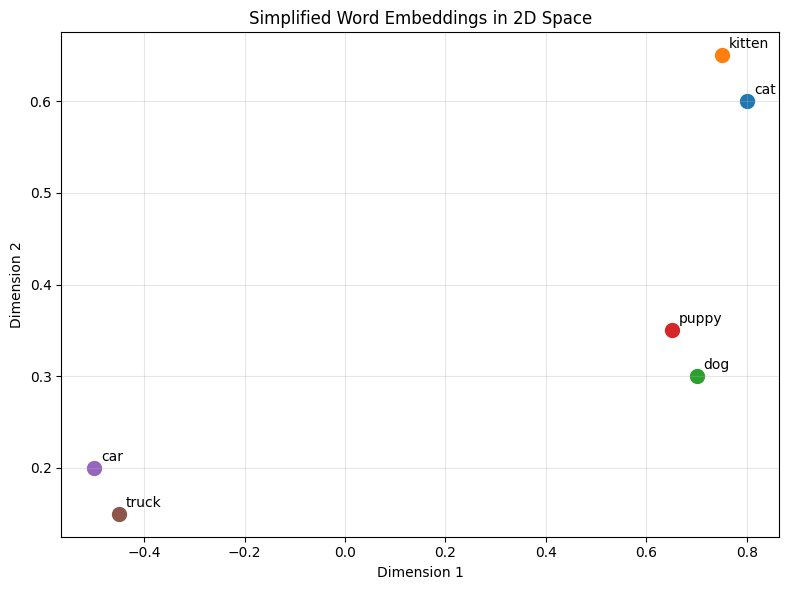

In [3]:
fig, ax = plt.subplots(figsize=(8,6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')
    
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Measuring Similarity

In [4]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

In [5]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity=cosine_similarity(cat_vector, kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [6]:
cosine_similarity(cat_vector, car_vector)

np.float64(-0.43718588548916804)

#### Creating our First Embeddings

In [9]:
import warnings
import os

# Suppress common non-critical warnings on Windows
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub")

In [8]:
# Huggingface And OpenAI Models

from langchain_huggingface import HuggingFaceEmbeddings

# Initialize a simple Embedding model (no API Key needed!)
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embeddings

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [10]:
# Create our first embeddings
text = "Hello, I am learning about embeddings!"

embedding = embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length: {len(embedding)}")
print(embedding)

Text: Hello, I am learning about embeddings!
Embedding length: 384
[-0.018163278698921204, -0.09955167025327682, 0.013816037215292454, -0.008125959895551205, 0.01415228471159935, 0.06406489759683609, -0.006253393366932869, -0.0030179028399288654, 0.025287210941314697, -0.020198645070195198, 0.024329708889126778, 0.07435066998004913, 0.05117722973227501, 0.022038495168089867, -0.058306191116571426, 0.015268214046955109, 0.023584384471178055, 0.09455391019582748, -0.0650884360074997, 0.013296639546751976, -0.020497532561421394, -0.05690861493349075, 0.030303331092000008, -0.08365611732006073, 0.026596277952194214, -0.01523144543170929, -0.04361540079116821, 0.05398401618003845, 0.09025715291500092, -0.08893883228302002, 0.03964463248848915, -0.008835062384605408, -0.030343763530254364, 0.07425564527511597, -0.05409923940896988, 0.11107995361089706, 0.03689985349774361, -0.008959821425378323, -0.061402447521686554, -0.0031433869153261185, 0.021958185359835625, 0.042208150029182434, -0.028

In [11]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence = embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])

[0.1304018199443817, -0.011870106682181358, -0.02811703272163868, 0.05123862996697426, -0.055974461138248444, 0.030191544443368912, 0.03016127645969391, 0.02469838596880436, -0.01837056316435337, 0.058766819536685944, -0.024953152984380722, 0.06015423685312271, 0.03983176872134209, 0.0332304909825325, -0.06131132319569588, -0.049373120069503784, -0.054863523691892624, -0.04007606580853462, 0.05642915144562721, 0.03915656358003616, -0.03473709896206856, -0.01324767991900444, 0.0319662019610405, -0.06349924206733704, -0.06017857417464256, 0.07823452353477478, -0.02830389142036438, -0.04744283854961395, 0.040359288454055786, -0.006630877498537302, -0.0667409598827362, -0.004191363696008921, -0.025311671197414398, 0.05334169790148735, 0.017428122460842133, -0.09792360663414001, 0.0060612973757088184, -0.06524162739515305, 0.04557264596223831, 0.023641813546419144, 0.0765848308801651, -0.010264383628964424, -0.004076847340911627, -0.06232277676463127, 0.033705271780490875, 0.018661111593246

#### References for different models with embed size information for understanding

In [12]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")


📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

